# Introduction
This notebook describes the most important questions regarding to the patterns of the electricity price in France using SQL. The database is first created in create_database.py from the cleaned dataframe from 01_data_cleaning.ipynb. 

# Load database

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

DB_path = "../electricity.db"
SQL_path = "../sql/analysis.sql"

conn = sqlite3.connect(DB_path)

In [13]:
with open(SQL_path, "r") as f:
    sql_script = f.read()

In [3]:
def run_query(query, conn):
    return pd.read_sql_query(query, conn)

In [14]:
queries = [q.strip() for q in sql_script.split(";") if q.strip()]

# Q1: Electricity price distribution

In [5]:
df_price = run_query(queries[0], conn)
df_price.head()

,Day-ahead Price (EUR/MWh)
0,23.86
1,22.39
2,20.59
3,16.81
4,17.41


In [6]:
df_price["Day-ahead Price (EUR/MWh)"].describe()

count    78912.000000
mean        82.573143
std         95.270461
min       -134.940000
25%         33.000000
50%         50.000000
75%         89.920000
max       2987.780000
Name: Day-ahead Price (EUR/MWh), dtype: float64

The electricity price in France is highly volatile. The price ranges from negative values to extremely high numbers.

# Q2: Yearly average price trend

In [7]:
df_yearly_avg = run_query(queries[1], conn)
df_yearly_avg

,year,avg_price
0,2016,36.748941
1,2017,44.965311
2,2018,50.198485
3,2019,39.449507
4,2020,32.203133
5,2021,109.171356
6,2022,275.878425
7,2023,96.855878
8,2024,58.018068


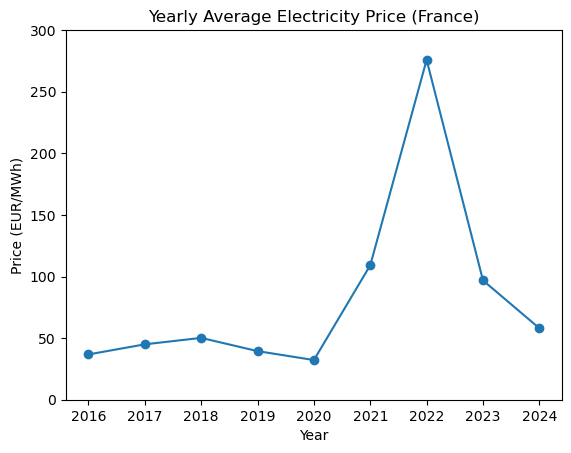

In [8]:
df_yearly_avg.plot(x = "year", y = "avg_price", marker = "o", legend = False)
plt.title("Yearly Average Electricity Price (France)")
plt.ylabel("Price (EUR/MWh)")
plt.ylim([0, 300])
plt.xlabel("Year")
plt.show()

Electricity price in France was geneniunly stable between 2016-2020. However, sharp increases in price appeared from 2021 and lasted to 2022. In 2023 the price descended back to the same level as 2021, and further decreased in 2024. The average price trend corresponds to the energy crisis in 2022.
# Q3: Yearly ranking of highest prices

In [17]:
df_yearly_rank = run_query(queries[2], conn)
df_yearly_rank.head(10)

,year,month,day,Day-ahead Price (EUR/MWh),rank_in_year
0,2016,11,7,874.01,1
1,2016,11,8,850.07,2
2,2016,11,14,829.79,3
3,2016,11,7,429.46,4
4,2016,11,8,267.65,5
5,2016,12,1,266.90,6
6,2016,11,15,243.24,7
7,2016,11,9,219.98,8
8,2016,11,29,200.07,9
9,2016,12,1,200.00,10


# Q4: Demand vs price relationship

In [18]:
df_demand_price = run_query(queries[3], conn)
df_demand_price.head()

,Day-ahead Total Load Forecast (MW)_load,Day-ahead Price (EUR/MWh)
0,58600.0,23.86
1,56550.0,22.39
2,56150.0,20.59
3,52600.0,16.81
4,49750.0,17.41


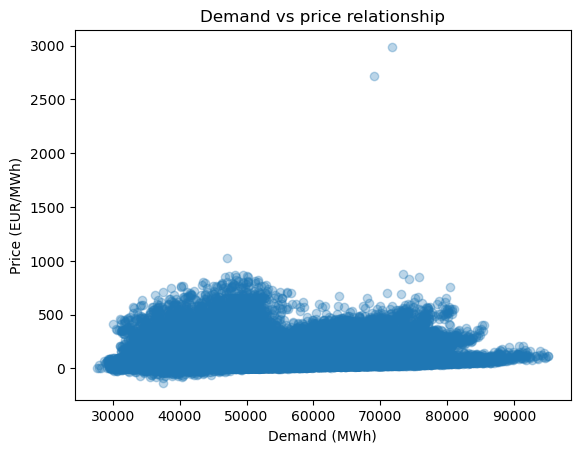

In [19]:
plt.scatter(
    df_demand_price["Day-ahead Total Load Forecast (MW)_load"],
    df_demand_price["Day-ahead Price (EUR/MWh)"],
    alpha= 0.3
)
plt.title("Demand vs price relationship")
plt.xlabel("Demand (MWh)")
plt.ylabel("Price (EUR/MWh)")
plt.show()

Demand and price doesn't show a clear linear relationship. This is probably due to the influences from multiple variables, such as the renewable generations, the gas price, and international exchange.
# Q5: Residual demand vs price relationship

In [20]:
df_resi_deman = run_query(queries[4], conn)
df_resi_deman.head()

,demand_bucket,avg_price
0,LOW,71.235745
1,MEDIUM,84.107257
2,HIGH,102.495757


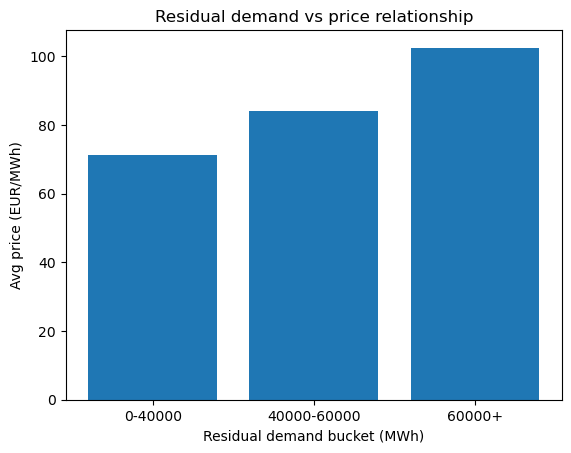

In [21]:
plt.bar(x = df_resi_deman["demand_bucket"], height = df_resi_deman["avg_price"])
plt.xticks(ticks = ["LOW", "MEDIUM", "HIGH"], labels = ["0-40000", "40000-60000", "60000+"])
plt.xlabel("Residual demand bucket (MWh)")
plt.ylabel("Avg price (EUR/MWh)")
plt.title("Residual demand vs price relationship")
plt.show()

Binning the residual demand into three boxes, the average price increases as the residual demand increases. 
# Q6: Hourly price

In [25]:
df_hour_price = run_query(queries[5], conn)

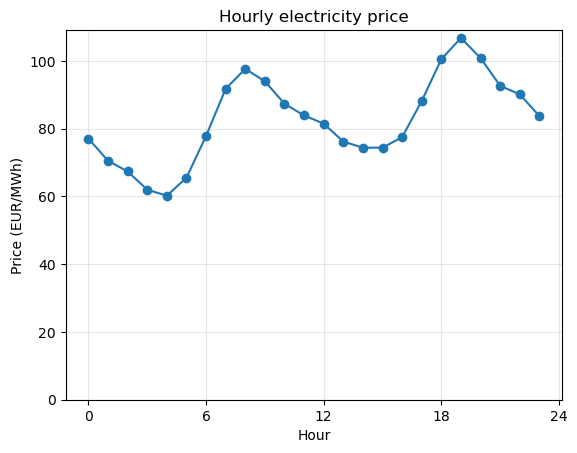

In [26]:
df_hour_price.plot(x = "hour", y = "hourly_price", marker = "o", legend = False)
plt.title("Hourly electricity price")
plt.xlabel("Hour")
plt.xticks(range(0, 25, 6))
plt.grid(alpha = 0.3)
plt.ylabel("Price (EUR/MWh)")
plt.yticks(range(0, 110, 20))
plt.show()

Electricity price show interday patterns. The highest price corresponds to evening peak hours when populations arrive home and utilise home appliances extensively at the same time period. The second price peaks at the morning rush hour when industries start to engage machinaries. Between the two peaks, the price decreases and then increases, influenced by demand, renewable generations, etc.
# Q7: Solar generation

In [27]:
df_solar_gen = run_query(queries[6], conn)

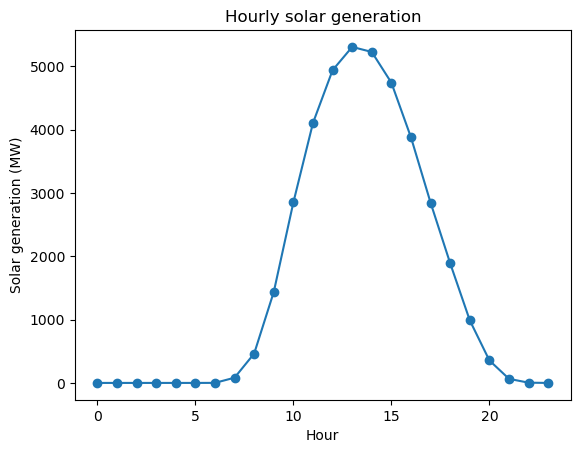

In [28]:
df_solar_gen.plot(x = "hour", y = "solar_avg_gen", marker = "o", legend = False)
plt.title("Hourly solar generation")
plt.xlabel("Hour")
plt.ylabel("Solar generation (MW)")
plt.show()

The hourly solar generation shows a bell shape with a longer tail on the left side. This corresponds perfectly to the solar exposure during one day: During the night there is no solar generation, and from midday to early afternoon the solar exposure is the highest, followed by the decrease of solar energy as the evening embarks.
# Q8: Negative price 

In [29]:
df_neg_price = run_query(queries[7], conn)
df_neg_price

,year,negative_hours
0,2016,2
1,2017,4
2,2018,11
3,2019,27
4,2020,102
5,2021,64
6,2022,4
7,2023,147
8,2024,352


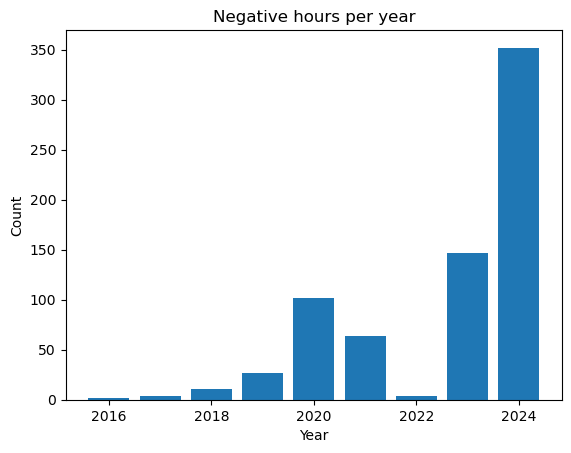

In [30]:
plt.bar(x = df_neg_price["year"], height = df_neg_price["negative_hours"])
plt.title("Negative hours per year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

The occurance of negative price appears to be increasing during 2016-2020 and shows a slight drop in 2021. In 2022 the negative price event dropped dramatically due to the structural disruption during the energy crisis. Since 2023, the negative price counts bounced back expotentially. 
# Q9.1: Extreme price events

In [32]:
df_top1pct_price = run_query(queries[8], conn)
df_top1pct_price

,Day-ahead Price (EUR/MWh)
0,2987.78
1,2712.99
2,1021.73
3,874.01
4,871.00
...,...
784,490.03
785,490.00
786,490.00
787,489.99


Top 1% price ranges from 490 to 2988 ERU/MWh. Price threshold 490 EUR/MWh will be used for the following extreme event analysis.

In [34]:
df_extreme_counts = run_query(queries[9], conn)
df_extreme_counts

,extreme_hours
0,785


Extreme events (top 1% price range) happen most frequently in 2022, followed by 2021. In addition, the scarcity events only occur 3 times in 2016 and not the other years between 2016-2024.
# Q9.2 Top 20 price spikes 

In [35]:
df_top20_price = run_query(queries[10], conn)
df_top20_price

,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_onshore,Day-ahead (MW)_solar,Day-ahead Price (EUR/MWh)
0,71750.0,3409.00,0.00,2987.78
1,69000.0,3252.48,0.00,2712.99
2,47050.0,2011.51,0.00,1021.73
3,73450.0,2052.35,0.00,874.01
4,49400.0,2552.89,1696.84,871.00
5,48250.0,2148.64,255.97,870.00
6,47400.0,2878.66,243.87,860.89
7,50100.0,1942.48,1772.16,859.45
8,48400.0,2227.14,3977.76,851.81
9,75750.0,1971.12,0.00,850.07


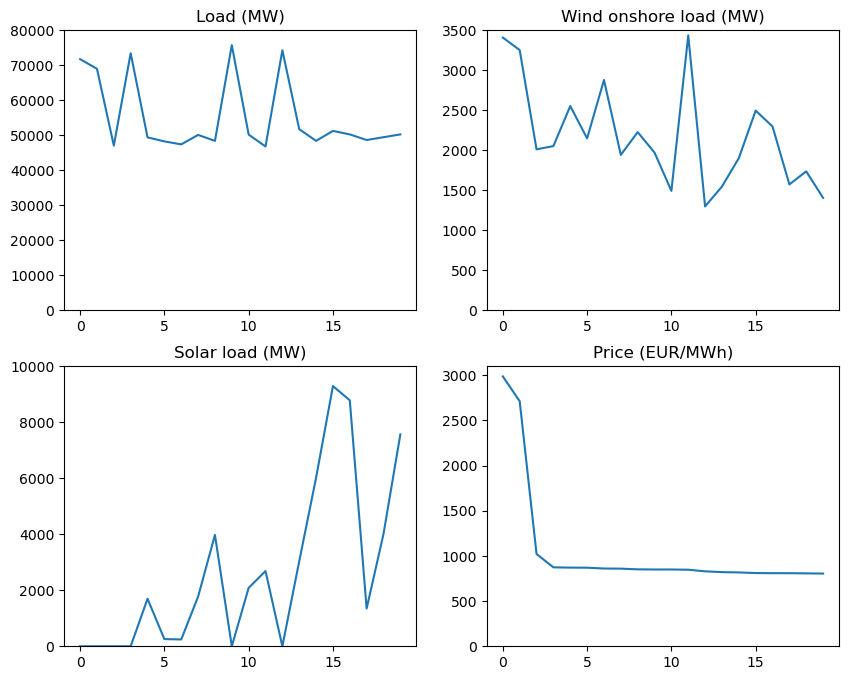

In [22]:
fig, axes = plt.subplots(2, 2, figsize = (10, 8))

axes[0, 0].plot(df_top20_price["Day-ahead Total Load Forecast (MW)_load"])
axes[0, 1].plot(df_top20_price["Day-ahead (MW)_wind_onshore"])
axes[1, 0].plot(df_top20_price["Day-ahead (MW)_solar"])
axes[1, 1].plot(df_top20_price["Day-ahead Price (EUR/MWh)"])

axes[0, 0].set_title("Load (MW)")
axes[0, 1].set_title("Wind onshore load (MW)")
axes[1, 0].set_title("Solar load (MW)")
axes[1, 1].set_title("Price (EUR/MWh)")

axes[0, 0].set_ylim([0, 80000])
axes[0, 1].set_ylim([0, 3500])
axes[1, 0].set_ylim([0, 10000])
axes[1, 1].set_ylim([0, 3100])
plt.show()

The demand peak fluctuations do not necessarily align with the price spikes. Renewable generations likely contributed to the decrease of the price peaks.
# Q9.3 Extreme events by hour

In [36]:
df_extrem_by_hour = run_query(queries[11], conn)
df_extrem_by_hour

,hour,extrem_by_hour,pct_of_all_extrem_by_hour
0,0,17,2.0
1,1,11,1.0
2,2,9,1.0
3,3,9,1.0
4,4,9,1.0
5,5,10,1.0
6,6,19,2.0
7,7,41,5.0
8,8,55,7.0
9,9,45,5.0


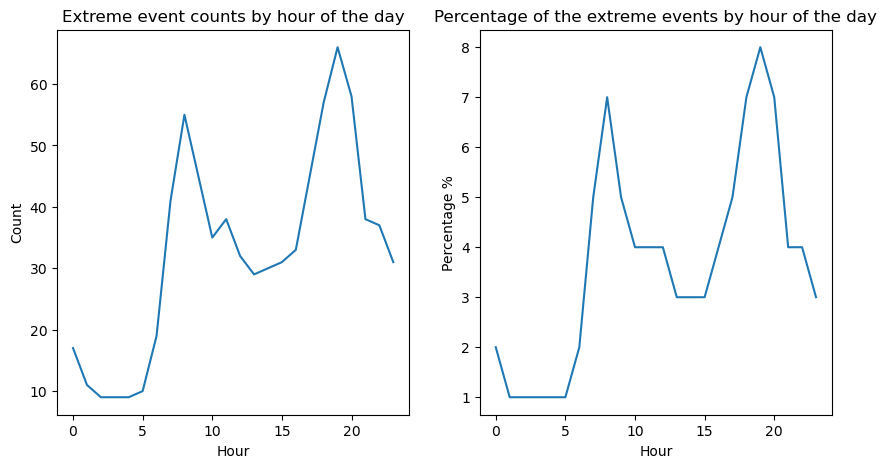

In [24]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot(df_extrem_by_hour["extrem_by_hour"])
ax[1].plot(df_extrem_by_hour["pct_of_all_extrem_by_hour"])
ax[0].set_title("Extreme event counts by hour of the day")
ax[1].set_title("Percentage of the extreme events by hour of the day")

ax[0].set_xlabel("Hour")
ax[1].set_xlabel("Hour")

ax[0].set_ylabel("Count")
ax[1].set_ylabel("Percentage %")
plt.show()

Extreme price occurs throughout the day. Price spikes distribution follows the same pattern as the price distribution within one day. The evening (from 18h) and morning (about 8h) rush hours contribute to the increase of the price spikes.
# Q9.4 Extreme events by month

In [37]:
df_extrem_by_month = run_query(queries[12], conn)
df_extrem_by_month

,month,count_extrem_month,pct_of_all_extrem_by_month
0,3,26,3.0
1,4,2,0.0
2,7,154,19.0
3,8,356,45.0
4,9,149,18.0
5,10,2,0.0
6,11,6,0.0
7,12,90,11.0


In [36]:
months_of_spikes = ["Mar", "Apr", "July", "Aug", "Sep", "Oct", "Nov", "Dec"]

Price extreme does not occur in Jan, Feb, May, and June. In August, the price spikes the most frequent, followed by July and September.

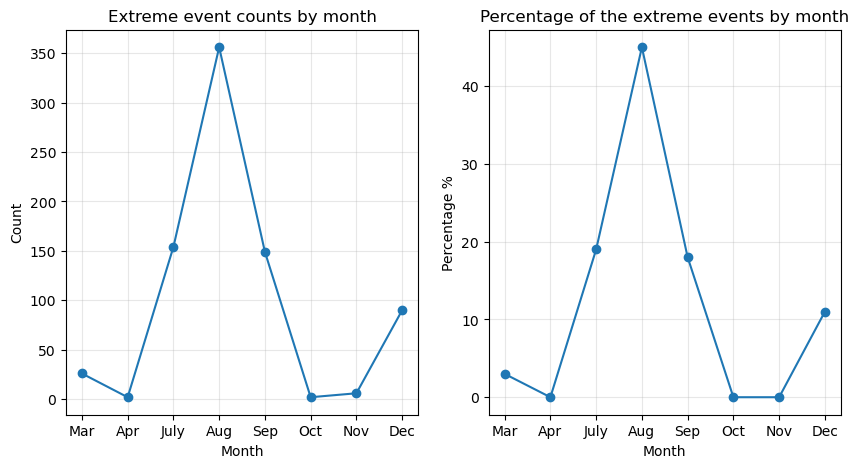

In [38]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot(df_extrem_by_month["count_extrem_month"], marker = "o")
ax[1].plot(df_extrem_by_month["pct_of_all_extrem_by_month"], marker = "o")
ax[0].set_title("Extreme event counts by month")
ax[1].set_title("Percentage of the extreme events by month")

ax[0].set_xticks(ticks = range(0, 8), labels = months_of_spikes)
ax[1].set_xticks(ticks = range(0, 8), labels = months_of_spikes)

ax[0].set_xlabel("Month")
ax[1].set_xlabel("Month")

ax[0].set_ylabel("Count")
ax[1].set_ylabel("Percentage %")
ax[0].grid(alpha = 0.3)
ax[1].grid(alpha = 0.3)

plt.show()

In November and December, which are the beginning of winter season, the price spikes much more than the rest of the year, which is likely due to the demand of heating. Jan and Feb show a decrease of price spikes, possibly due to the vacation seasons. Summer months (July-Sep) show a stable price extreme event counts, which is likely due to the increasing usage of air-conditioning in offices, transportations, and homes.
# Q9.5 System conditions during extreme prices

In [38]:
df_during_extreme = run_query(queries[13], conn)
df_during_extreme 

,avg_load,avg_wind_offshore,avg_wind_onshore,avg_solar,avg_price
0,50830.44586,0.0,2411.348051,2764.225057,596.691631


In [39]:
df_overall = run_query(queries[14], conn)
df_overall 

,avg_load,avg_wind_offshore,avg_wind_onshore,avg_solar,avg_price
0,52082.498517,58.911953,3869.03169,1631.433275,82.573143


In [40]:
df_compare = pd.merge(df_during_extreme, df_overall, how = "outer", sort = True)
new_col = ["During extreme", "Overall"]
df_compare.insert(loc = 0, column = "Condition", value = new_col)
df_compare

,Condition,avg_load,avg_wind_offshore,avg_wind_onshore,avg_solar,avg_price
0,During extreme,50830.445860,0.000000,2411.348051,2764.225057,596.691631
1,Overall,52082.498517,58.911953,3869.031690,1631.433275,82.573143


Comparing the conditions, during extreme price events, the average load is slightly lower, wind onshore generations are one third lower, while the solar generations are higher than overall events. The average price is significantly higher during extreme events. The average wind offshore generations is not discussed due to the limited data entries.

In [140]:
conn.close()

# Conclusions
This SQL analysis explored the main drivers and patterns of French day-ahead electricity prices between 2016-2024.

Several key findings emerged:

**Long-term trends**

Average electricity prices remained relatively stable between 2016-2020 before rising sharply during the 2021-2022 European energy crisis. Prices peaked in 2022 and grandually returned toward historical levels in 2023-2024.

**Demand effects**

